# Notebook 01 — ETL Pipeline (Community-Based VFX Scoring)

This notebook builds a **graph-community approach** to identify VFX movies:

1. Load the full TMDB dataset into **DuckDB** (no upfront filtering)
2. Clean and type-cast all columns
3. Build a bipartite graph from cleaned data — Movies ↔ Production Companies ↔ Directors
4. Run **Louvain community detection** on this graph
5. **Score each community** for VFX relevance using:
   - Known VFX production companies (**70% weight** — primary signal)
   - VFX technical keyword hits in movie overviews (**30% weight** — secondary signal)
6. **Communities with the highest VFX scores** are selected as VFX communities
7. All movies inside top VFX communities are flagged `is_vfx = 1`
8. Export filtered Parquet + Neo4j CSVs for downstream notebooks

> **Key design decisions:**
> - Community built first (no pre-scoring), VFX scoring applied *after*
> - Characterisation is **community-level**: `vfx_company_ratio` (0–1) + `vfx_percentage` (0–100%) — no blending
> - `vfx_percentage` = % of movies in a community that matched a keyword signal (interpretability metric)
> - Threshold is `> 0`: any community scoring above 0 touched at least one signal; threshold is set to `> 0` by default, adjusted for precision
> - No genre signals — only VFX technical terms and known VFX studio presence


In [4]:
import duckdb
import pandas as pd
import numpy as np
import networkx as nx
from community import best_partition          # python-louvain
from pathlib import Path
import re, os

DATA_DIR = Path("../data")
RAW_CSV  = DATA_DIR / "TMDB_all_movies.csv"

assert RAW_CSV.exists(), (
    f"Download TMDB_all_movies.csv from Kaggle and place it at {RAW_CSV}\n"
    "Dataset: https://www.kaggle.com/datasets/alanvourch/tmdb-movies-daily-updates"
)

con = duckdb.connect()
print("DuckDB version:", duckdb.__version__)

DuckDB version: 0.10.3


## Step 1 — Load Raw CSV (Full Dataset, No Genre Filter)

In [5]:
con.execute(f"""
    CREATE OR REPLACE TABLE raw_movies AS
    SELECT * FROM read_csv_auto('{RAW_CSV}',
        nullstr=['', 'NA', 'N/A', 'None'],
        header=true,
        ignore_errors=true
    )
""")

total = con.execute("SELECT COUNT(*) AS rows FROM raw_movies").fetchone()[0]
print(f"Raw rows loaded: {total:,}")
con.execute("DESCRIBE raw_movies").df()

Raw rows loaded: 1,186,656


,column_name,column_type,null,key,default,extra
0,id,BIGINT,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,vote_average,DOUBLE,YES,None,None,None
3,vote_count,DOUBLE,YES,None,None,None
4,status,VARCHAR,YES,None,None,None
5,release_date,DATE,YES,None,None,None
6,revenue,DOUBLE,YES,None,None,None
7,runtime,DOUBLE,YES,None,None,None
8,budget,DOUBLE,YES,None,None,None
9,imdb_id,VARCHAR,YES,None,None,None


## Step 2 — Base Cleaning (No VFX Filter Yet)

Clean and type-cast all columns. We keep **all** movies at this stage — the VFX filtering happens after community scoring.

In [6]:
con.execute("""
    CREATE OR REPLACE TABLE base_movies AS
    SELECT
        CAST(id AS BIGINT)                                      AS movie_id,
        TRIM(title)                                             AS title,
        TRIM(original_title)                                    AS original_title,
        TRY_CAST(release_date AS DATE)                          AS release_date,
        YEAR(TRY_CAST(release_date AS DATE))                    AS release_year,

        -- Crew
        TRIM(director)                                          AS director,
        TRIM(producers)                                         AS producers,
        TRIM(writers)                                           AS writers,
        TRIM(director_of_photography)                           AS dop,
        TRIM(music_composer)                                    AS composer,
        TRIM("cast")                                            AS cast_list,

        -- Content
        TRIM(genres)                                            AS genres,
        TRIM(overview)                                          AS overview,
        TRIM(tagline)                                           AS tagline,
        TRIM(original_language)                                 AS original_language,
        TRIM(production_companies)                              AS production_companies,

        -- Numerics
        COALESCE(TRY_CAST(popularity AS DOUBLE), 0.0)           AS popularity,
        COALESCE(TRY_CAST(vote_average AS DOUBLE), 0.0)         AS vote_average,
        COALESCE(TRY_CAST(vote_count AS BIGINT), 0)             AS vote_count,
        COALESCE(TRY_CAST(runtime AS INTEGER), 0)               AS runtime,
        NULLIF(TRY_CAST(budget AS DOUBLE), 0)                   AS budget,
        NULLIF(TRY_CAST(revenue AS DOUBLE), 0)                  AS revenue,

        CASE
            WHEN NULLIF(TRY_CAST(budget AS DOUBLE), 0) IS NOT NULL
             AND NULLIF(TRY_CAST(revenue AS DOUBLE), 0) IS NOT NULL
            THEN ROUND(
                (
                    NULLIF(TRY_CAST(revenue AS DOUBLE), 0)
                    - NULLIF(TRY_CAST(budget AS DOUBLE), 0)
                )
                / NULLIF(TRY_CAST(budget AS DOUBLE), 0) * 100.0,
            2)
            ELSE NULL
        END                                                     AS roi_pct,

        CASE
            WHEN TRY_CAST(vote_count AS BIGINT) >= 50
             AND TRY_CAST(vote_average AS DOUBLE) >= 7.0
            THEN 1 ELSE 0
        END                                                     AS is_successful

    FROM raw_movies
    WHERE id IS NOT NULL
      AND title IS NOT NULL
      AND TRIM(title) != ''
""")

n = con.execute("SELECT COUNT(*) FROM base_movies").fetchone()[0]

print(f"Base (cleaned) rows: {n:,}")

con.execute("SELECT * FROM base_movies LIMIT 3").df()

Base (cleaned) rows: 1,186,644


,movie_id,title,original_title,release_date,release_year,director,producers,writers,dop,composer,...,original_language,production_companies,popularity,vote_average,vote_count,runtime,budget,revenue,roi_pct,is_successful
0,2,Ariel,Ariel,1988-10-21,1988,Aki Kaurismäki,Aki Kaurismäki,Aki Kaurismäki,Timo Salminen,None,...,fi,Villealfa Filmproductions,1.6384,7.106,371,73,NaN,NaN,NaN,1
1,3,Shadows in Paradise,Varjoja paratiisissa,1986-10-17,1986,Aki Kaurismäki,Mika Kaurismäki,Aki Kaurismäki,Timo Salminen,None,...,fi,Villealfa Filmproductions,2.7136,7.300,435,74,NaN,NaN,NaN,1
2,5,Four Rooms,Four Rooms,1995-12-09,1995,"Robert Rodriguez, Allison Anders, Quentin Tara...","Quentin Tarantino, Alexandre Rockwell, Lawrenc...","Allison Anders, Robert Rodriguez, Alexandre Ro...","Rodrigo García, Guillermo Navarro, Phil Parmet...",Combustible Edison,...,en,"Miramax, A Band Apart",2.6464,5.900,2819,98,4000000.0,4257354.0,6.43,0


## Step 3 — Crew Name Validation Macro

In [7]:
JUNK_TOKENS = "('jr.', 'jr', 'sr.', 'sr', 'ii', 'iii', 'iv', 'x', 'unknown', 'n/a', 'none', 'tbd', 'tba')"

con.execute(f"""
    CREATE OR REPLACE MACRO is_valid_name(n) AS (
        n IS NOT NULL
        AND LENGTH(TRIM(n)) >= 3
        AND LOWER(TRIM(n)) NOT IN {JUNK_TOKENS}
        AND REGEXP_MATCHES(TRIM(n), '.*[A-Za-z].*')
    )
""")
print("✅ is_valid_name macro created")

✅ is_valid_name macro created


## Step 4 — Build the VFX Scoring Knowledge Base

Two curated lists drive the community VFX scoring:

### 4a. Known VFX Production Companies
These studios are directly associated with visual effects work. A movie produced by or connected through
these companies is a strong signal of VFX involvement.

### 4b. VFX Technical Keyword Signals
Only **specific VFX technical terms** are used — terms that unambiguously refer to visual effects craft.
Generic genre words like "Action" or "Adventure" are deliberately excluded to avoid false positives.

> **No genre signals are used in this notebook.** Genre matching was removed because Action/Adventure
> movies are not inherently VFX movies (e.g. a low-budget action thriller has no CGI).
> The community graph handles indirect evidence without needing genre as a crutch.


In [8]:
# ── VFX Production Companies (direct signal, high weight) ─────────────────
VFX_COMPANIES = [
    # Major VFX studios
    "Industrial Light & Magic", "ILM",
    "Weta Digital", "Weta Workshop", "WetaFX",
    "Double Negative", "DNEG",
    "Moving Picture Company", "MPC",
    "Framestore",
    "Digital Domain",
    "Rhythm & Hues",
    "Sony Pictures Imageworks",
    "Cinesite",
    "Rising Sun Pictures",
    "Animal Logic",
    "Blur Studio",
    "Image Engine",
    "Luma Pictures",
    "Scanline VFX",
    "Method Studios",
    "Pixel Envy",
    "Pixar",
    "DreamWorks Animation",
    "Blue Sky Studios",
    "ReelFX",
    "Boss Film Studios",
    "Pacific Title",
    "Stan Winston Studio",
    "KNB EFX Group",
    "Legacy Effects",
    "BUF",
    "Mikros Image",
    "Unit Image",
    # VFX-heavy major studios
    "Marvel Studios",
    "Legendary Entertainment",
    "Lucasfilm",
    "Bad Robot",
]

# ── VFX Technical Keyword Signals ─────────────────────────────────────────
# ONLY specific VFX technical terms — no genre words (Action, Adventure, etc.)
# These terms unambiguously indicate visual effects craft work.
VFX_ROLE_KEYWORDS = [
    "visual effects",
    "vfx",
    "cgi",
    "computer-generated imagery",
    "computer generated",
    "digital effects",
    "special effects",
    "sfx",
    "motion capture",
    "mocap",
    "performance capture",
    "compositing",
    "digital compositing",
    "matte painting",
    "digital matte",
    "creature effects",
    "practical effects",
    "pyrotechnics",
    "prosthetics makeup",
    "animatronics",
    "digital intermediate",
    "3d rendering",
    "cg animation",
    "particle effects",
    "green screen",
    "chroma key",
    "wire removal",
    "rotoscoping",
    "match moving",
    "fluid simulation",
]

# ── Genre signals REMOVED intentionally ───────────────────────────────────
# Action, Adventure, Science Fiction, Fantasy etc. are NOT used.
# Reason: These genres are too broad and introduce false positives.
# The community graph captures indirect VFX involvement without genre noise.

print(f"VFX companies in knowledge base : {len(VFX_COMPANIES)}")
print(f"VFX technical keyword signals   : {len(VFX_ROLE_KEYWORDS)}")
print("Genre signals                   : DISABLED (intentionally removed)")


VFX companies in knowledge base : 38
VFX technical keyword signals   : 30
Genre signals                   : DISABLED (intentionally removed)


## Step 5 — Build the Production-Company Graph Directly from Raw Data

We construct a **bipartite graph** straight from the cleaned dataset — **no pre-scoring**:
- **Movie nodes** (`m_<id>`)
- **Production company nodes** (`c_<name>`)
- **Director nodes** (`d_<name>`)

Two movies are indirectly connected when they share a production company or director.
Community detection runs on this raw structural graph.


In [9]:
print("Building graph (Movie ↔ ProductionCompany ↔ Director) from raw data...")

import networkx as nx

G = nx.Graph()

# --- SAFE QUERY (no missing columns) ---
df_graph = con.execute("""
    SELECT movie_id, title, production_companies, director,
           genres, overview
    FROM base_movies
    WHERE movie_id IS NOT NULL
""").df()

for _, row in df_graph.iterrows():
    mid = int(row["movie_id"])
    node_id = f"m_{mid}"

    # --- Movie node ---
    G.add_node(
        node_id,
        ntype="movie",
        movie_id=mid,
        title=row.get("title") or "",
        genres=row.get("genres") or "",
        overview=row.get("overview") or "",
        production_companies=row.get("production_companies") or ""
    )

    # --- Production companies ---
    pc_raw = row.get("production_companies")

    if isinstance(pc_raw, str) and pc_raw.strip():
        # split safely (adjust here if your data is JSON instead)
        for company in pc_raw.split(","):
            company = company.strip()

            if company:
                cnode = f"c_{company.lower()}"

                if not G.has_node(cnode):
                    G.add_node(
                        cnode,
                        ntype="company",
                        name=company
                    )

                G.add_edge(node_id, cnode)

    # --- Director ---
    director = row.get("director")

    if isinstance(director, str):
        director = director.strip()

        if director:
            dnode = f"d_{director.lower()}"

            if not G.has_node(dnode):
                G.add_node(
                    dnode,
                    ntype="director",
                    name=director
                )

            G.add_edge(node_id, dnode)

# --- STATS ---
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")
print(f"Movie nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('ntype') == 'movie'):,}")
print(f"Company nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('ntype') == 'company'):,}")
print(f"Director nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('ntype') == 'director'):,}")

Building graph (Movie ↔ ProductionCompany ↔ Director) from raw data...
Graph nodes: 1,806,863
Graph edges: 1,886,234
Movie nodes: 1,186,644
Company nodes: 208,198
Director nodes: 412,021


## Step 6 — Louvain Community Detection

Run the **Louvain algorithm** on the raw structural graph.
Each cluster of movies + companies + directors becomes a `community_id`.

At this stage communities are purely structural — no VFX scoring yet.
The VFX scoring happens *after* communities are formed (next step).


In [10]:
print("Running Louvain community detection on raw graph...")
partition = best_partition(G, random_state=42)

# Assign community IDs back to nodes
nx.set_node_attributes(G, partition, "community_id")

num_communities = len(set(partition.values()))
print(f"Total communities detected: {num_communities:,}")

# Build community → movie list mapping
from collections import defaultdict, Counter
community_movies = defaultdict(list)   # community_id → list of movie node data

for node, data in G.nodes(data=True):
    if data.get("ntype") == "movie":
        cid = partition[node]
        community_movies[cid].append(data)

print(f"Communities with at least 1 movie: {len(community_movies):,}")

# Size distribution
sizes = sorted([len(v) for v in community_movies.values()], reverse=True)
print(f"Largest community: {sizes[0]:,} movies")
print(f"Median community size: {sizes[len(sizes)//2]:,} movies")
print(f"Single-movie communities: {sum(1 for s in sizes if s == 1):,}")


Running Louvain community detection on raw graph...
Total communities detected: 403,546
Communities with at least 1 movie: 403,546
Largest community: 78,970 movies
Median community size: 1 movies
Single-movie communities: 341,118


## Step 7 — Characterise Each Community for VFX Relevance

For every Louvain community we compute two **independent, interpretable metrics**:

| Metric | Type | Definition |
|--------|------|------------|
| `vfx_company_ratio` | Ratio 0–1 | Fraction of *company nodes* in the community that are known VFX studios (ILM, Weta, DNEG …) |
| `vfx_percentage` | Percentage 0–100 | % of *member movies* whose overview mentions at least one VFX technical term |

These are **descriptive metrics — not a blended score**.  
A community is declared a **VFX community** if it clears either threshold independently:

```
is_vfx_community = (vfx_company_ratio > 0)   ← at least one known VFX studio present
                 OR (vfx_percentage   >= 20)  ← ≥ 20% of movies mention VFX terms
```

**Why OR logic?**
- A community built around ILM but whose overviews don't say "visual effects" explicitly → still VFX
- A community with no listed VFX studio but where 30% of movies mention "CGI" or "motion capture" → still VFX
- Blending them into a single score (e.g. 0.70×ratio + 0.30×pct) would create an uninterpretable decimal.
  Instead we keep both metrics transparent and use a human-readable OR condition.


In [11]:
# ── Collect company nodes per community ──────────────────────────────────────
vfx_company_set_lower = {c.lower() for c in VFX_COMPANIES}

community_company_stats = defaultdict(lambda: {"total": 0, "vfx": 0})
for node, data in G.nodes(data=True):
    if data.get("ntype") == "company":
        cid = partition[node]
        community_company_stats[cid]["total"] += 1
        name_lower = data["name"].lower()
        if any(v.lower() in name_lower for v in VFX_COMPANIES):
            community_company_stats[cid]["vfx"] += 1

# ── Keyword signal: % of movies in community that mention a VFX technical term ─
VFX_ROLE_KEYWORDS_LOWER = [k.lower() for k in VFX_ROLE_KEYWORDS]

def movie_has_keyword_signal(movie_data):
    """Return True if movie overview contains any VFX technical term."""
    text = (movie_data.get("overview", "") or "").lower()
    return any(k in text for k in VFX_ROLE_KEYWORDS_LOWER)

# ── Characterise each community ───────────────────────────────────────────────
community_stats_rows = []

for cid, movies in community_movies.items():
    n_movies = len(movies)

    # VFX company ratio: what fraction of this community's companies are known VFX studios
    stats = community_company_stats[cid]
    vfx_company_ratio = round(stats["vfx"] / stats["total"], 4) if stats["total"] > 0 else 0.0

    # VFX percentage: % of member movies that mention a VFX keyword in their overview
    kw_hits = sum(1 for m in movies if movie_has_keyword_signal(m))
    vfx_percentage = round(kw_hits / n_movies * 100.0, 2) if n_movies > 0 else 0.0

    community_stats_rows.append({
        "community_id":      cid,
        "movie_count":       n_movies,
        "vfx_company_ratio": vfx_company_ratio,   # 0–1: fraction of companies that are VFX studios
        "vfx_percentage":    vfx_percentage,       # 0–100: % of movies mentioning VFX keywords
    })

community_stats_df = pd.DataFrame(community_stats_rows).sort_values(
    ["vfx_company_ratio", "vfx_percentage"], ascending=False
).reset_index(drop=True)

print(f"Total communities characterised: {len(community_stats_df):,}")
print(f"Communities with any VFX company (ratio > 0)   : {(community_stats_df.vfx_company_ratio > 0).sum():,}")
print(f"Communities with vfx_percentage >= 20%%        : {(community_stats_df.vfx_percentage >= 20).sum():,}")
print(f"Communities meeting EITHER criterion           : {((community_stats_df.vfx_company_ratio > 0) | (community_stats_df.vfx_percentage >= 20)).sum():,}")
print("\nTop 15 communities by VFX company ratio:")
community_stats_df.head(15)


Total communities characterised: 403,546
Communities with any VFX company (ratio > 0)   : 16,536
Communities with vfx_percentage >= 20%%        : 696
Communities meeting EITHER criterion           : 17,206

Top 15 communities by VFX company ratio:


,community_id,movie_count,vfx_company_ratio,vfx_percentage
0,29969,1,1.0,100.00
1,75198,1,1.0,100.00
2,228193,1,1.0,100.00
3,250537,1,1.0,100.00
4,255119,1,1.0,100.00
5,307273,1,1.0,100.00
6,378020,1,1.0,100.00
7,378215,1,1.0,100.00
8,47843,2,1.0,50.00
9,133332,2,1.0,50.00


## Step 8 — Select VFX Communities

A community is a **VFX community** if it meets at least one of:

| Criterion | Threshold | Rationale |
|-----------|-----------|-----------|
| `vfx_company_ratio > 0` | Any known VFX studio present | Hard signal — studio attachment is unambiguous |
| `vfx_percentage >= 20` | ≥ 20% of movies mention VFX terms | Soft signal — 1-in-5 movies explicitly referencing VFX is a meaningful cluster signal |

The 20% keyword threshold is tunable (`KW_THRESHOLD`). Lowering it increases recall; raising it increases precision.


Keyword threshold (vfx_percentage >= 20.0%)
Total communities detected       : 403,546
  → Has VFX company              : 16,536
  → Has VFX keyword >= 20.0%      : 696
  → VFX communities (EITHER)     : 17,206
  → Non-VFX communities          : 386,340


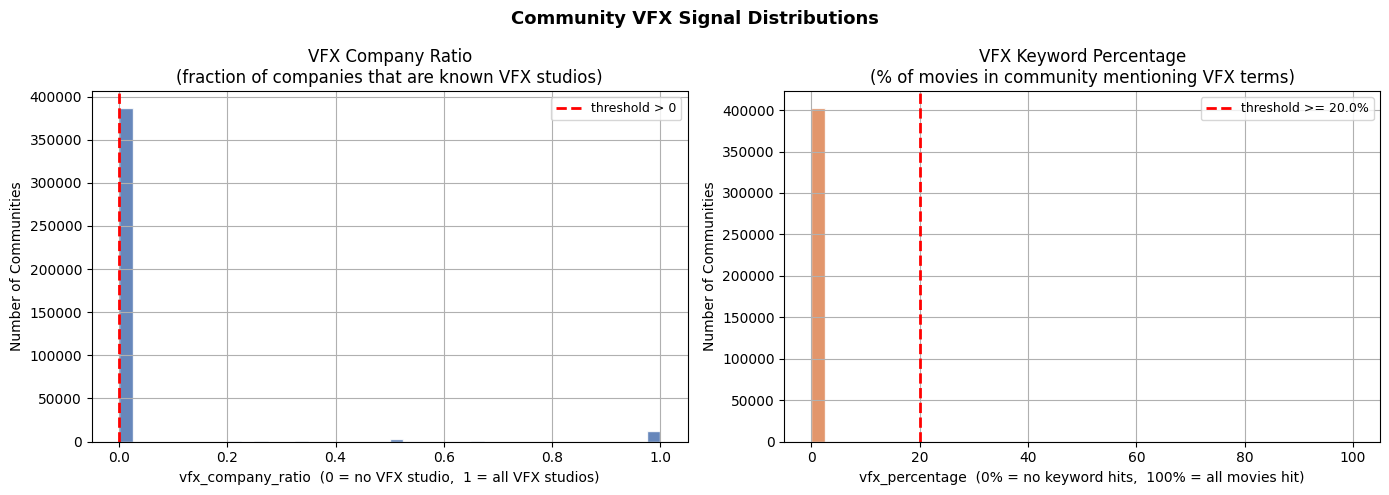


Top 20 VFX communities:


,community_id,movie_count,vfx_company_ratio,vfx_percentage,is_vfx_community
0,29969,1,1.0,100.00,1
1,75198,1,1.0,100.00,1
2,228193,1,1.0,100.00,1
3,250537,1,1.0,100.00,1
4,255119,1,1.0,100.00,1
5,307273,1,1.0,100.00,1
6,378020,1,1.0,100.00,1
7,378215,1,1.0,100.00,1
8,47843,2,1.0,50.00,1
9,133332,2,1.0,50.00,1


In [12]:
import matplotlib.pyplot as plt

# ── Thresholds ────────────────────────────────────────────────────────────────
# vfx_company_ratio > 0  : at least one known VFX studio in the community (hard signal)
# vfx_percentage >= 20   : ≥ 20% of community movies mention a VFX keyword (soft signal)
# A community qualifies if EITHER condition is met.
KW_THRESHOLD = 20.0  # tunable: lower = more recall, higher = more precision

has_vfx_company = community_stats_df["vfx_company_ratio"] > 0
has_vfx_keyword = community_stats_df["vfx_percentage"] >= KW_THRESHOLD

community_stats_df["is_vfx_community"] = (has_vfx_company | has_vfx_keyword).astype(int)

vfx_community_ids = set(
    community_stats_df.loc[community_stats_df["is_vfx_community"] == 1, "community_id"]
)

print(f"Keyword threshold (vfx_percentage >= {KW_THRESHOLD}%)")
print(f"Total communities detected       : {len(community_stats_df):,}")
print(f"  → Has VFX company              : {has_vfx_company.sum():,}")
print(f"  → Has VFX keyword >= {KW_THRESHOLD}%      : {has_vfx_keyword.sum():,}")
print(f"  → VFX communities (EITHER)     : {len(vfx_community_ids):,}")
print(f"  → Non-VFX communities          : {len(community_stats_df) - len(vfx_community_ids):,}")

# ── Plot: two clear distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Community VFX Signal Distributions", fontsize=13, fontweight="bold")

# Panel 1: VFX Company Ratio
ax1 = axes[0]
community_stats_df["vfx_company_ratio"].hist(bins=40, ax=ax1, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(0, color="red", linestyle="--", linewidth=2, label="threshold > 0")
ax1.set_title("VFX Company Ratio\n(fraction of companies that are known VFX studios)")
ax1.set_xlabel("vfx_company_ratio  (0 = no VFX studio,  1 = all VFX studios)")
ax1.set_ylabel("Number of Communities")
ax1.legend(fontsize=9)

# Panel 2: VFX Percentage
ax2 = axes[1]
community_stats_df["vfx_percentage"].hist(bins=40, ax=ax2, color="#DD8452", edgecolor="white", alpha=0.85)
ax2.axvline(KW_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"threshold >= {KW_THRESHOLD}%")
ax2.set_title("VFX Keyword Percentage\n(% of movies in community mentioning VFX terms)")
ax2.set_xlabel("vfx_percentage  (0% = no keyword hits,  100% = all movies hit)")
ax2.set_ylabel("Number of Communities")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / "community_vfx_distributions.png", dpi=120)
plt.show()

print("\nTop 20 VFX communities:")
community_stats_df[community_stats_df["is_vfx_community"] == 1][
    ["community_id", "movie_count", "vfx_company_ratio", "vfx_percentage", "is_vfx_community"]
].head(20)


## Step 9 — Propagate Community Labels to Each Movie

Each movie inherits from its community:
- `community_id` — which Louvain cluster it belongs to
- `vfx_company_ratio` — fraction of companies in its community that are known VFX studios (0–1)
- `vfx_percentage` — % of movies in its community that mentioned a VFX keyword (0–100)
- `is_vfx` — 1 if the community is a VFX community (company ratio > 0 OR keyword % ≥ 20), else 0

No blended score. Both metrics stay separate and human-readable at the movie level.


In [13]:
# Map movie_id → community_id
movie_community = {}
for node, data in G.nodes(data=True):
    if data.get("ntype") == "movie":
        movie_community[data["movie_id"]] = partition[node]

# Build community-level lookup tables
comm_idx = community_stats_df.set_index("community_id")
community_company_ratio_map = comm_idx["vfx_company_ratio"].to_dict()
community_vfx_pct_map       = comm_idx["vfx_percentage"].to_dict()
community_is_vfx_map        = comm_idx["is_vfx_community"].to_dict()

# Load base_movies from DuckDB
base_df = con.execute("SELECT * FROM base_movies").df()

# Propagate community metrics to each movie
base_df["community_id"]       = base_df["movie_id"].map(movie_community)
base_df["vfx_company_ratio"]  = base_df["community_id"].map(community_company_ratio_map).fillna(0.0).round(4)
base_df["vfx_percentage"]     = base_df["community_id"].map(community_vfx_pct_map).fillna(0.0).round(2)
base_df["is_vfx"]             = base_df["community_id"].map(community_is_vfx_map).fillna(0).astype(int)

clean_movies = base_df.copy()

print(f"Total movies           : {len(clean_movies):,}")
print(f"Movies flagged is_vfx=1: {clean_movies.is_vfx.sum():,} ({100*clean_movies.is_vfx.mean():.1f}%)")
print(f"\nvfx_company_ratio stats (VFX movies only):")
print(clean_movies[clean_movies.is_vfx == 1]["vfx_company_ratio"].describe())
print(f"\nvfx_percentage stats (VFX movies only):")
print(clean_movies[clean_movies.is_vfx == 1]["vfx_percentage"].describe())

print("\nTop 15 movies (by community VFX company ratio):")
clean_movies[clean_movies.is_vfx == 1][
    ["title", "release_year", "community_id", "vfx_company_ratio", "vfx_percentage",
     "genres", "production_companies"]
].sort_values(["vfx_company_ratio", "vfx_percentage"], ascending=False).head(15)


Total movies           : 1,186,644
Movies flagged is_vfx=1: 664,057 (56.0%)

vfx_company_ratio stats (VFX movies only):
count    664057.000000
mean          0.292967
std           0.185663
min           0.000000
25%           0.193500
50%           0.253000
75%           0.299200
max           1.000000
Name: vfx_company_ratio, dtype: float64

vfx_percentage stats (VFX movies only):
count    664057.000000
mean          0.225677
std           3.006934
min           0.000000
25%           0.040000
50%           0.060000
75%           0.130000
max         100.000000
Name: vfx_percentage, dtype: float64

Top 15 movies (by community VFX company ratio):


,title,release_year,community_id,vfx_company_ratio,vfx_percentage,genres,production_companies
160304,The Last Days of Pompeii,1926.0,29969,1.0,100.00,History,Società Italiana Grandi Films
314436,Pinnernation The Movie,2008.0,75198,1.0,100.00,Documentary,Ill-Advised Films
751372,The Green Goddess,2021.0,228193,1.0,100.00,"Comedy, Drama",Enlightening Films
811874,Lost in the Sky,2023.0,250537,1.0,100.00,"Science Fiction, Adventure",Kojan Film
824098,Rex Dandy and The Case of the Missing Millionaire,2001.0,255119,1.0,100.00,Comedy,Jagpro Films
956655,Animation Pie,1974.0,307273,1.0,100.00,Documentary,Mt. Diablo Unified School District Advanced Pr...
1126268,Legend of Marina,2016.0,378020,1.0,100.00,None,Form Films
1126712,Barba Lounger,1996.0,378215,1.0,100.00,Animation,Matt Rhodes Films
213106,The Star Dreamer,2002.0,47843,1.0,50.00,"Documentary, History","Vesterholt Film & Tv, SVT"
496800,Traces of the Soul,2018.0,133332,1.0,50.00,Documentary,None


## Step 10 — Annotate Communities with Descriptive Labels

For each VFX community we generate a human-readable label capturing:
- Dominant genres of member movies
- Top production companies
- Known VFX studios present
- Top directors
- Sample highest-scoring titles


In [14]:
community_labels = {}

for cid in community_stats_df["community_id"].tolist():
    subset = clean_movies[clean_movies["community_id"] == cid]

    genre_counts = Counter(
        g.strip()
        for gs in subset["genres"].dropna()
        for g in gs.split(",")
        if g.strip()
    )
    top_genres = [g for g, _ in genre_counts.most_common(3)]

    company_counts = Counter(
        c.strip()
        for cs in subset["production_companies"].dropna()
        for c in cs.split(",")
        if c.strip() and len(c.strip()) >= 3
    )
    top_companies = [c for c, _ in company_counts.most_common(3)]

    top_directors = subset["director"].dropna().value_counts().head(3).index.tolist()

    vfx_present = [
        c for c in top_companies
        if any(v.lower() in c.lower() for v in VFX_COMPANIES)
    ]

    genre_str  = ", ".join(top_genres[:2]) if top_genres else "Mixed"
    studio_str = top_companies[0] if top_companies else "Unknown Studio"
    dir_str    = top_directors[0] if top_directors else "Various"
    label = f"{genre_str} | Led by {studio_str} | e.g. {dir_str}"

    community_labels[cid] = {
        "label": label,
        "dominant_genres": top_genres,
        "top_companies": top_companies,
        "vfx_companies_present": vfx_present,
        "top_directors": top_directors,
        "sample_titles": subset.sort_values("vfx_company_ratio", ascending=False)["title"].head(5).tolist(),
    }

community_stats_df["label"]                 = community_stats_df["community_id"].map(lambda c: community_labels.get(c, {}).get("label", ""))
community_stats_df["dominant_genres"]       = community_stats_df["community_id"].map(lambda c: ", ".join(community_labels.get(c, {}).get("dominant_genres", [])[:2]))
community_stats_df["top_companies"]         = community_stats_df["community_id"].map(lambda c: ", ".join(community_labels.get(c, {}).get("top_companies", [])[:2]))
community_stats_df["vfx_companies_present"] = community_stats_df["community_id"].map(lambda c: ", ".join(community_labels.get(c, {}).get("vfx_companies_present", [])) or "None detected")
# vfx_percentage already set during scoring step (% of movies in community matching keyword)
community_stats_df["top_directors"]         = community_stats_df["community_id"].map(lambda c: ", ".join(community_labels.get(c, {}).get("top_directors", [])[:2]))
community_stats_df["sample_titles"]         = community_stats_df["community_id"].map(lambda c: " | ".join(community_labels.get(c, {}).get("sample_titles", [])))

print("── Top 10 VFX Communities with Labels ──")
display_cols = ["community_id", "movie_count", "vfx_company_ratio", "vfx_percentage",
                "is_vfx_community", "dominant_genres", "top_companies", "vfx_companies_present",
                "top_directors", "sample_titles"]
print(community_stats_df[display_cols].head(10).to_string(index=False))

# Detailed profile for top 5 VFX communities
top5 = community_stats_df[community_stats_df["is_vfx_community"] == 1].head(5)["community_id"].tolist()
print("\n── Detailed Profile: Top 5 VFX Communities ──")
for cid in top5:
    info   = community_labels[cid]
    subset = clean_movies[clean_movies["community_id"] == cid]
    stats  = community_stats_df[community_stats_df["community_id"] == cid].iloc[0]
    print(f"\nCommunity {cid}  (movies={len(subset):,})")
    print(f"  Label                : {info['label']}")
    print(f"  VFX company ratio    : {stats['vfx_company_ratio']:.4f}  (fraction of companies that are known VFX studios)")
    print(f"  VFX keyword %        : {stats['vfx_percentage']:.2f}%  (% of movies mentioning VFX terms)")
    print(f"  Is VFX community     : {'Yes' if stats['is_vfx_community'] else 'No'}")
    print(f"  Dominant genres      : {info['dominant_genres']}")
    print(f"  Top companies        : {info['top_companies']}")
    print(f"  VFX studios found    : {info['vfx_companies_present'] or 'None in top-3'}")
    print(f"  Top directors        : {info['top_directors']}")
    print(f"  Sample VFX titles    : {info['sample_titles']}")


── Top 10 VFX Communities with Labels ──
 community_id  movie_count  vfx_company_ratio  vfx_percentage  is_vfx_community            dominant_genres                                                      top_companies                                              vfx_companies_present                                       top_directors                                                          sample_titles
        29969            1                1.0           100.0                 1                    History                                      Società Italiana Grandi Films                                      Società Italiana Grandi Films                     Amleto Palermi, Carmine Gallone                                               The Last Days of Pompeii
        75198            1                1.0           100.0                 1                Documentary                                                  Ill-Advised Films                                                  Ill-Advi

## Step 11 — Filter to Final VFX Movie Dataset

Apply three filters to the VFX-flagged movies:
1. `is_vfx = 1` — must belong to a VFX community
2. `release_year >= 2000` — modern VFX era only (CGI became mainstream post-2000)
3. `runtime > 30` — exclude short films, trailers, featurettes


In [15]:
vfx_movies = clean_movies[
    (clean_movies["is_vfx"] == 1) &
    (clean_movies["release_year"] >= 2000) &
    (clean_movies["runtime"] > 80)
].copy().reset_index(drop=True)

print(f"After is_vfx=1 filter            : {clean_movies.is_vfx.sum():,}")
print(f"After release_year >= 2000 filter : {((clean_movies.is_vfx==1) & (clean_movies.release_year>=2000)).sum():,}")
print(f"After runtime > 30 min filter     : {len(vfx_movies):,}  ← final VFX dataset")
print(f"\nvfx_company_ratio stats:")
print(vfx_movies["vfx_company_ratio"].describe())
print(f"\nvfx_percentage stats:")
print(vfx_movies["vfx_percentage"].describe())

con.register("vfx_movies", vfx_movies)

vfx_movies[["title", "release_year", "runtime", "community_id",
             "vfx_company_ratio", "vfx_percentage", "genres", "production_companies"]] \
    .sort_values(["vfx_company_ratio", "vfx_percentage"], ascending=False).head(20)


After is_vfx=1 filter            : 664,057
After release_year >= 2000 filter : 364,440
After runtime > 30 min filter     : 141,126  ← final VFX dataset

vfx_company_ratio stats:
count    141126.000000
mean          0.271029
std           0.162401
min           0.000000
25%           0.201200
50%           0.250600
75%           0.295500
max           1.000000
Name: vfx_company_ratio, dtype: float64

vfx_percentage stats:
count    141126.000000
mean          0.166322
std           2.081267
min           0.000000
25%           0.040000
50%           0.060000
75%           0.120000
max         100.000000
Name: vfx_percentage, dtype: float64


,title,release_year,runtime,community_id,vfx_company_ratio,vfx_percentage,genres,production_companies
113102,The Green Goddess,2021.0,84,228193,1.0,100.00,"Comedy, Drama",Enlightening Films
119737,Rex Dandy and The Case of the Missing Millionaire,2001.0,100,255119,1.0,100.00,Comedy,Jagpro Films
88651,Traces of the Soul,2018.0,86,133332,1.0,50.00,Documentary,None
120175,"History, Mystery & Oyssey: Six Portland Animators",2023.0,91,133332,1.0,50.00,Documentary,Clear Spot Films
4914,The Combination,2009.0,96,857,1.0,25.00,Drama,See Thru Films
26500,The Believers,2012.0,83,14515,1.0,25.00,Documentary,None
38894,Weather Gazers,2010.0,98,29033,1.0,25.00,Documentary,None
77569,The Combination Redemption,2019.0,103,857,1.0,25.00,Drama,Handshake Films
78558,We Believe in Dinosaurs,2020.0,98,14515,1.0,25.00,Documentary,137 Films
83231,Wolves Return,2019.0,90,29033,1.0,25.00,Documentary,"Settebello Filmproduktion, SRF"


## Step 12 — Quality Report

In [16]:
con.execute("""
    SELECT
        COUNT(*)                                            AS total_vfx_movies,
        COUNT(director)                                     AS has_director,
        COUNT(producers)                                    AS has_producers,
        COUNT(dop)                                          AS has_dop,
        COUNT(composer)                                     AS has_composer,
        COUNT(writers)                                      AS has_writers,
        COUNT(cast_list)                                    AS has_cast,
        COUNT(budget)                                       AS has_budget,
        COUNT(revenue)                                      AS has_revenue,
        COUNT(roi_pct)                                      AS has_roi,
        SUM(is_successful)                                  AS successful_count,
        ROUND(AVG(vfx_company_ratio), 4)                    AS avg_vfx_company_ratio,
        ROUND(AVG(vfx_percentage), 2)                       AS avg_vfx_percentage,
        MIN(release_year)                                   AS earliest_year,
        MAX(release_year)                                   AS latest_year,
        ROUND(AVG(runtime), 1)                              AS avg_runtime_min
    FROM "vfx_movies"
""").df()


,total_vfx_movies,has_director,has_producers,has_dop,has_composer,has_writers,has_cast,has_budget,has_revenue,has_roi,successful_count,avg_vfx_company_ratio,avg_vfx_percentage,earliest_year,latest_year,avg_runtime_min
0,141126,134697,89275,71014,43782,109181,131576,16187,14162,8121,4787.0,0.271,0.17,2000.0,2030.0,106.7


## Step 13 — Export Parquet

In [18]:
PARQUET_PATH = DATA_DIR / "clean_movies.parquet"
con.execute(f"COPY raw_movies TO '{PARQUET_PATH}' (FORMAT PARQUET, COMPRESSION SNAPPY)")
print(f"✅ Parquet saved: {PARQUET_PATH}  ({os.path.getsize(PARQUET_PATH)/1e6:.1f} MB)")

community_stats_df.to_parquet(DATA_DIR / "community_vfx_stats.parquet", index=False)
print(f"✅ Community stats saved: {DATA_DIR / 'community_vfx_stats.parquet'}")

community_stats_df.to_csv(DATA_DIR / "community_vfx_stats.csv", index=False)
print(f"✅ Community stats CSV saved: {DATA_DIR / 'community_vfx_stats.csv'}")

print(f"\nCommunity stats sample:")
print(community_stats_df[
    ["community_id", "movie_count", "vfx_company_ratio", "vfx_percentage", "is_vfx_community"]
].head(10).to_string(index=False))


✅ Parquet saved: ..\data\clean_movies.parquet  (442.4 MB)
✅ Community stats saved: ..\data\community_vfx_stats.parquet
✅ Community stats CSV saved: ..\data\community_vfx_stats.csv

Community stats sample:
 community_id  movie_count  vfx_company_ratio  vfx_percentage  is_vfx_community
        29969            1                1.0           100.0                 1
        75198            1                1.0           100.0                 1
       228193            1                1.0           100.0                 1
       250537            1                1.0           100.0                 1
       255119            1                1.0           100.0                 1
       307273            1                1.0           100.0                 1
       378020            1                1.0           100.0                 1
       378215            1                1.0           100.0                 1
        47843            2                1.0            50.0              

## Step 14 — Export Neo4j CSVs

Community VFX fields exported to Movie nodes:
- `vfx_company_ratio` — fraction of community's companies that are known VFX studios
- `vfx_percentage`    — % of community's movies that mentioned a VFX keyword  
- `community_id`      — Louvain community assignment
- `is_vfx`            — 1 if VFX community, 0 otherwise

Only movies passing the final filter (is_vfx=1, year≥2000, runtime>30) are exported.


In [19]:
NEO_DIR = DATA_DIR / "neo4j_csv"
NEO_DIR.mkdir(parents=True, exist_ok=True)

# ── Movie nodes ──────────────────────────────────────────────────────────────
con.execute(f"""
    COPY (
        SELECT DISTINCT
            movie_id, title, release_year, vote_average, vote_count,
            runtime, budget, revenue, roi_pct, original_language,
            genres, overview, tagline, popularity, is_successful,
            vfx_company_ratio, vfx_percentage, community_id, is_vfx
        FROM vfx_movies
        WHERE movie_id IS NOT NULL AND title IS NOT NULL
    ) TO '{NEO_DIR}/nodes_Movie.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Movie.csv'").fetchone()[0]
print(f"Movie nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(director) AS name
        FROM vfx_movies
        WHERE is_valid_name(director)
    ) TO '{NEO_DIR}/nodes_Director.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Director.csv'").fetchone()[0]
print(f"Director nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(actor_name) AS name
        FROM (
            SELECT UNNEST(string_split(cast_list, ',')) AS actor_name
            FROM vfx_movies
            WHERE cast_list IS NOT NULL AND TRIM(cast_list) != ''
        )
        WHERE is_valid_name(TRIM(actor_name))
    ) TO '{NEO_DIR}/nodes_Actor.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Actor.csv'").fetchone()[0]
print(f"Actor nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(p) AS name
        FROM (
            SELECT UNNEST(string_split(producers, ',')) AS p
            FROM vfx_movies
            WHERE producers IS NOT NULL AND TRIM(producers) != ''
        )
        WHERE is_valid_name(TRIM(p))
    ) TO '{NEO_DIR}/nodes_Producer.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Producer.csv'").fetchone()[0]
print(f"Producer nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(w) AS name
        FROM (
            SELECT UNNEST(string_split(writers, ',')) AS w
            FROM vfx_movies
            WHERE writers IS NOT NULL AND TRIM(writers) != ''
        )
        WHERE is_valid_name(TRIM(w))
    ) TO '{NEO_DIR}/nodes_Writer.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Writer.csv'").fetchone()[0]
print(f"Writer nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(dop) AS name
        FROM vfx_movies
        WHERE is_valid_name(dop)
    ) TO '{NEO_DIR}/nodes_DOP.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_DOP.csv'").fetchone()[0]
print(f"DOP nodes: {n:,}")

con.execute(f"""
    COPY (
        SELECT DISTINCT TRIM(composer) AS name
        FROM vfx_movies
        WHERE is_valid_name(composer)
    ) TO '{NEO_DIR}/nodes_Composer.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/nodes_Composer.csv'").fetchone()[0]
print(f"Composer nodes: {n:,}")

print("\n✅ All node CSVs exported.")


Movie nodes: 141,126
Director nodes: 58,144
Actor nodes: 761,866
Producer nodes: 107,767
Writer nodes: 96,993
DOP nodes: 23,898
Composer nodes: 17,202

✅ All node CSVs exported.


## Step 15 — Export Relationship CSVs

In [20]:
# DIRECTED_BY
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(director) AS director_name
        FROM vfx_movies
        WHERE movie_id IS NOT NULL AND is_valid_name(director)
    ) TO '{NEO_DIR}/rel_DIRECTED_BY.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_DIRECTED_BY.csv'").fetchone()[0]
print(f"DIRECTED_BY: {n:,}")

# ACTED_IN
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(actor_name) AS actor_name
        FROM (
            SELECT movie_id, UNNEST(string_split(cast_list, ',')) AS actor_name
            FROM vfx_movies
            WHERE cast_list IS NOT NULL
        )
        WHERE movie_id IS NOT NULL AND is_valid_name(TRIM(actor_name))
    ) TO '{NEO_DIR}/rel_ACTED_IN.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_ACTED_IN.csv'").fetchone()[0]
print(f"ACTED_IN: {n:,}")

# PRODUCED_BY
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(p) AS producer_name
        FROM (
            SELECT movie_id, UNNEST(string_split(producers, ',')) AS p
            FROM vfx_movies
            WHERE producers IS NOT NULL
        )
        WHERE movie_id IS NOT NULL AND is_valid_name(TRIM(p))
    ) TO '{NEO_DIR}/rel_PRODUCED_BY.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_PRODUCED_BY.csv'").fetchone()[0]
print(f"PRODUCED_BY: {n:,}")

# WRITTEN_BY
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(w) AS writer_name
        FROM (
            SELECT movie_id, UNNEST(string_split(writers, ',')) AS w
            FROM vfx_movies
            WHERE writers IS NOT NULL
        )
        WHERE movie_id IS NOT NULL AND is_valid_name(TRIM(w))
    ) TO '{NEO_DIR}/rel_WRITTEN_BY.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_WRITTEN_BY.csv'").fetchone()[0]
print(f"WRITTEN_BY: {n:,}")

# SHOT_BY
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(dop) AS dop_name
        FROM vfx_movies
        WHERE movie_id IS NOT NULL AND is_valid_name(dop)
    ) TO '{NEO_DIR}/rel_SHOT_BY.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_SHOT_BY.csv'").fetchone()[0]
print(f"SHOT_BY: {n:,}")

# SCORE_BY
con.execute(f"""
    COPY (
        SELECT DISTINCT movie_id, TRIM(composer) AS composer_name
        FROM vfx_movies
        WHERE movie_id IS NOT NULL AND is_valid_name(composer)
    ) TO '{NEO_DIR}/rel_SCORE_BY.csv' (HEADER, FORMAT CSV)
""")
n = con.execute(f"SELECT COUNT(*) FROM '{NEO_DIR}/rel_SCORE_BY.csv'").fetchone()[0]
print(f"SCORE_BY: {n:,}")

print("\n✅ All relationship CSVs exported.")


DIRECTED_BY: 134,583
ACTED_IN: 2,028,640
PRODUCED_BY: 301,961
WRITTEN_BY: 202,202
SHOT_BY: 70,988
SCORE_BY: 43,752

✅ All relationship CSVs exported.


## Step 16 — Final Business Preview

Sanity check: top VFX directors by ROI, using the community-scored dataset.


In [21]:
print("Top VFX directors by avg ROI (final filtered dataset):")
con.execute("""
    SELECT director,
           COUNT(*)                        AS films,
           ROUND(AVG(roi_pct), 1)          AS avg_roi,
           ROUND(AVG(vote_average), 2)     AS avg_rating,
           ROUND(AVG(vfx_company_ratio), 4) AS avg_vfx_company_ratio,
           ROUND(AVG(vfx_percentage), 2)   AS avg_vfx_percentage
    FROM vfx_movies
    WHERE director IS NOT NULL
      AND roi_pct IS NOT NULL
    GROUP BY director
    HAVING COUNT(*) >= 3
    ORDER BY avg_roi DESC
    LIMIT 10
""").df()


Top VFX directors by avg ROI (final filtered dataset):


,director,films,avg_roi,avg_rating,avg_vfx_company_ratio,avg_vfx_percentage
0,Ron Howard,14,17548395.6,6.86,0.1670,0.16
1,Kimo Stamboel,3,299956.5,6.10,0.2495,0.03
2,P. Vasu,3,116603.4,3.17,0.2238,0.04
3,Ram Babu Gurung,4,69583.7,6.93,0.1952,0.12
4,Roman Karimov,4,25446.6,5.90,0.2512,0.03
5,Haruo Sotozaki,3,9625.7,7.47,0.0652,0.18
6,John Carney,3,4592.8,7.51,0.2955,0.06
7,"Ariel Schulman, Henry Joost",4,4299.7,6.28,0.2673,0.12
8,Damien Leone,3,3906.0,6.60,0.2246,0.20
9,Alex Kendrick,7,3438.2,7.66,0.1920,0.21


In [22]:
print("VFX community signal breakdown:")
con.execute("""
    SELECT
        COUNT(DISTINCT community_id)                                AS num_vfx_communities,
        -- Company-driven: at least one known VFX studio in community
        SUM(CASE WHEN vfx_company_ratio > 0 THEN 1 ELSE 0 END)     AS company_signal_movies,
        -- Keyword-driven: community keyword % >= 20 (no VFX company)
        SUM(CASE WHEN vfx_company_ratio = 0
             AND vfx_percentage >= 20 THEN 1 ELSE 0 END)           AS keyword_only_signal_movies,
        -- Both signals
        SUM(CASE WHEN vfx_company_ratio > 0
             AND vfx_percentage >= 20 THEN 1 ELSE 0 END)           AS both_signals_movies,
        ROUND(AVG(vfx_company_ratio), 4)                            AS avg_vfx_company_ratio,
        ROUND(AVG(vfx_percentage), 2)                               AS avg_vfx_percentage,
        MIN(release_year)                                           AS earliest_year,
        MAX(release_year)                                           AS latest_year
    FROM vfx_movies
""").df()


VFX community signal breakdown:


,num_vfx_communities,company_signal_movies,keyword_only_signal_movies,both_signals_movies,avg_vfx_company_ratio,avg_vfx_percentage,earliest_year,latest_year
0,5455,141012.0,114.0,13.0,0.271,0.17,2000.0,2030.0


---
## Summary

| Step | What happened |
|------|---------------|
| Load | All TMDB movies loaded into DuckDB — no upfront genre filter |
| Clean | Type-cast, validate, compute ROI |
| Knowledge Base | VFX companies + VFX technical keywords defined (no genre signals) |
| Graph | Bipartite Movie ↔ ProductionCompany ↔ Director graph built from cleaned data |
| Community | Louvain algorithm detects structural clusters |
| **Characterise** | Each community gets `vfx_company_ratio` (0–1) + `vfx_percentage` (0–100%) — **no blending** |
| **Select** | Community is VFX if `vfx_company_ratio > 0` OR `vfx_percentage >= 20%` |
| **Filter** | Final dataset: `is_vfx=1` AND `release_year >= 2000` AND `runtime > 30 min` |
| Propagate | Every qualifying movie inherits `vfx_company_ratio`, `vfx_percentage`, `community_id`, `is_vfx` |
| Export | Parquet + Neo4j CSVs with clean, interpretable columns — no blended score |

**Column meanings (no ambiguity):**
- `vfx_company_ratio` — fraction of companies in movie's community that are known VFX studios (0 = none, 1 = all)
- `vfx_percentage` — % of movies in movie's community that mentioned a VFX keyword (0–100)
- `is_vfx` — binary flag: 1 if community passed either threshold, 0 otherwise
